# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Companion Dependency Dataset](https://www.kaggle.com/datasets/harpartapsingh13/ai-companion-dependency-prediction-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai_companion_dependency_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,user_id,age,gender,occupation_status,education_level,income_level,relationship_status,living_situation,country_region,ai_chatbot_platform,primary_use_case,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,loneliness_score,emotional_attachment_score,real_relationship_satisfaction,prefers_ai_over_humans,sleep_hours,sleep_quality_score,exercise_hours_weekly,anxiety_score,depression_score,stress_score,self_esteem_score,academic_or_work_performance_change,therapy_attendance,dependency_risk_label
0,U0001,21,Male,Employed Full-Time,High School,Lower-Middle,In a Relationship,With Partner,South America,ChatGPT,Learning,0.00,6.60,0.51,3.28,1,4.5,2.0,8.1,No,7.3,9.1,3.3,3.5,3.0,1.0,9.5,Improved,No,Low
1,U0002,34,Male,Student,Graduate,Upper-Middle,Single,Alone,North America,Character.AI,Productivity/Work,2.36,2.88,3.73,8.12,5,5.9,2.3,5.4,No,7.5,3.5,0.9,4.6,2.4,5.2,4.7,Same,No,Moderate
2,U0003,43,Male,Employed Full-Time,Graduate,Low,Single,Alone,Europe,Character.AI,Entertainment,0.07,4.56,0.49,3.02,4,1.1,1.0,8.3,No,6.8,8.3,7.6,1.0,1.0,3.2,7.2,Improved,No,Low
3,U0004,29,Non-binary,Employed Full-Time,Graduate,Low,Single,With Family,Asia,ChatGPT,Therapy-Substitute,0.44,5.66,0.88,5.28,7,3.2,1.8,6.7,No,9.5,8.9,7.4,2.7,1.5,2.6,9.0,Improved,No,Low
4,U0005,25,Female,Student,Graduate,Upper-Middle,In a Relationship,With Roommates,South America,ChatGPT,Therapy-Substitute,0.00,6.56,0.29,3.09,8,1.0,1.0,10.0,No,8.5,10.0,6.5,1.0,1.0,1.0,9.9,Improved,No,Low


## last Five row

In [4]:
df.tail()

,user_id,age,gender,occupation_status,education_level,income_level,relationship_status,living_situation,country_region,ai_chatbot_platform,primary_use_case,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,loneliness_score,emotional_attachment_score,real_relationship_satisfaction,prefers_ai_over_humans,sleep_hours,sleep_quality_score,exercise_hours_weekly,anxiety_score,depression_score,stress_score,self_esteem_score,academic_or_work_performance_change,therapy_attendance,dependency_risk_label
995,U0996,35,Female,Student,Undergraduate,Low,In a Relationship,With Partner,Asia,Character.AI,Productivity/Work,1.95,3.38,1.91,6.37,4,2.0,5.1,6.5,No,7.4,4.7,5.1,5.6,3.4,7.2,4.8,Declined,No,Low
996,U0997,19,Male,Student,Undergraduate,Lower-Middle,Married,With Family,North America,Claude,Entertainment,2.91,5.11,2.49,6.74,6,4.4,3.5,6.6,No,7.3,7.6,6.2,2.7,6.6,5.5,10.0,Improved,Yes,Moderate
997,U0998,24,Male,Employed Part-Time,High School,Lower-Middle,Single,With Family,South America,Character.AI,Productivity/Work,0.00,5.36,1.44,3.77,5,4.5,2.7,9.6,No,7.1,10.0,6.0,3.2,3.8,3.3,7.9,Improved,No,Low
998,U0999,24,Male,Employed Part-Time,High School,Lower-Middle,Single,With Family,Europe,ChatGPT,Productivity/Work,0.81,3.37,2.80,6.94,4,3.5,4.7,6.7,No,7.0,5.8,5.0,3.4,5.8,4.9,6.1,Same,No,Low
999,U1000,33,Male,Employed Part-Time,Undergraduate,Lower-Middle,Single,With Roommates,Europe,ChatGPT,Therapy-Substitute,0.00,6.99,1.92,3.67,5,1.0,1.0,9.2,No,10.0,10.0,5.2,1.4,1.0,2.0,7.7,Improved,No,Low


## Shape of our dataset

In [5]:
df.shape

(1000, 30)

## List out all columns

In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation_status', 'education_level',
       'income_level', 'relationship_status', 'living_situation',
       'country_region', 'ai_chatbot_platform', 'primary_use_case',
       'daily_ai_chat_hours', 'human_social_interaction_hours',
       'social_media_hours_daily', 'screen_time_total_hours',
       'number_of_close_friends', 'loneliness_score',
       'emotional_attachment_score', 'real_relationship_satisfaction',
       'prefers_ai_over_humans', 'sleep_hours', 'sleep_quality_score',
       'exercise_hours_weekly', 'anxiety_score', 'depression_score',
       'stress_score', 'self_esteem_score',
       'academic_or_work_performance_change', 'therapy_attendance',
       'dependency_risk_label'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

user_id                                 object
age                                      int64
gender                                  object
occupation_status                       object
education_level                         object
income_level                            object
relationship_status                     object
living_situation                        object
country_region                          object
ai_chatbot_platform                     object
primary_use_case                        object
daily_ai_chat_hours                    float64
human_social_interaction_hours         float64
social_media_hours_daily               float64
screen_time_total_hours                float64
number_of_close_friends                  int64
loneliness_score                       float64
emotional_attachment_score             float64
real_relationship_satisfaction         float64
prefers_ai_over_humans                  object
sleep_hours                            float64
sleep_quality

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   user_id                              1000 non-null   object 
 1   age                                  1000 non-null   int64  
 2   gender                               1000 non-null   object 
 3   occupation_status                    1000 non-null   object 
 4   education_level                      1000 non-null   object 
 5   income_level                         1000 non-null   object 
 6   relationship_status                  1000 non-null   object 
 7   living_situation                     1000 non-null   object 
 8   country_region                       1000 non-null   object 
 9   ai_chatbot_platform                  1000 non-null   object 
 10  primary_use_case                     1000 non-null   object 
 11  daily_ai_chat_hours            

## Check Null Value

In [9]:
df.isnull().sum()

user_id                                0
age                                    0
gender                                 0
occupation_status                      0
education_level                        0
income_level                           0
relationship_status                    0
living_situation                       0
country_region                         0
ai_chatbot_platform                    0
primary_use_case                       0
daily_ai_chat_hours                    0
human_social_interaction_hours         0
social_media_hours_daily               0
screen_time_total_hours                0
number_of_close_friends                0
loneliness_score                       0
emotional_attachment_score             0
real_relationship_satisfaction         0
prefers_ai_over_humans                 0
sleep_hours                            0
sleep_quality_score                    0
exercise_hours_weekly                  0
anxiety_score                          0
depression_score

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,loneliness_score,emotional_attachment_score,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,anxiety_score,depression_score,stress_score,self_esteem_score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,29.940000,1.613470,3.98939,2.508770,6.093740,4.096000,5.072900,4.562700,6.000400,7.045000,6.535400,4.032600,4.543200,4.115100,5.014100,5.977000
std,9.033493,1.309653,1.51918,1.369145,2.625688,2.118318,2.443298,2.466711,2.322015,1.177328,2.084147,1.945184,2.211372,2.267846,2.054174,2.183726
min,15.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,22.000000,0.500000,2.94750,1.520000,4.140000,3.000000,3.200000,2.500000,4.400000,6.200000,5.200000,2.700000,2.900000,2.200000,3.500000,4.600000
50%,30.000000,1.440000,3.93500,2.510000,5.770000,4.000000,5.100000,4.500000,6.050000,7.100000,6.500000,4.000000,4.500000,4.000000,5.000000,6.000000
75%,38.000000,2.530000,5.00250,3.420000,7.805000,5.000000,6.800000,6.225000,7.800000,7.800000,8.125000,5.400000,6.000000,5.700000,6.400000,7.500000
max,44.000000,6.520000,9.75000,6.700000,14.300000,11.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.800000,10.000000,10.000000,10.000000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

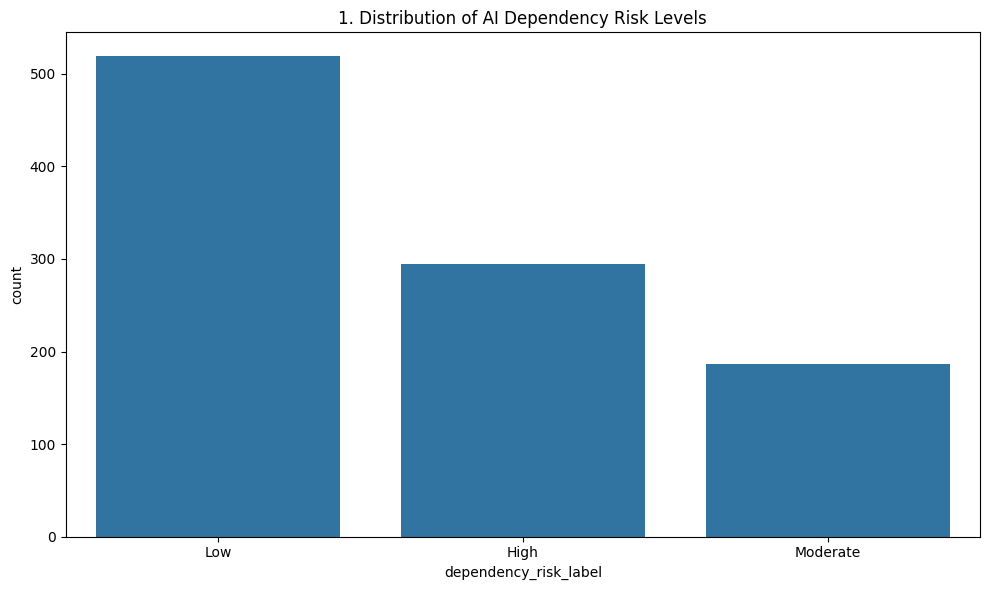

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='dependency_risk_label', order=df['dependency_risk_label'].value_counts().index)
plt.title(f'{plot_no}. Distribution of AI Dependency Risk Levels')
show_fig()
plot_no += 1

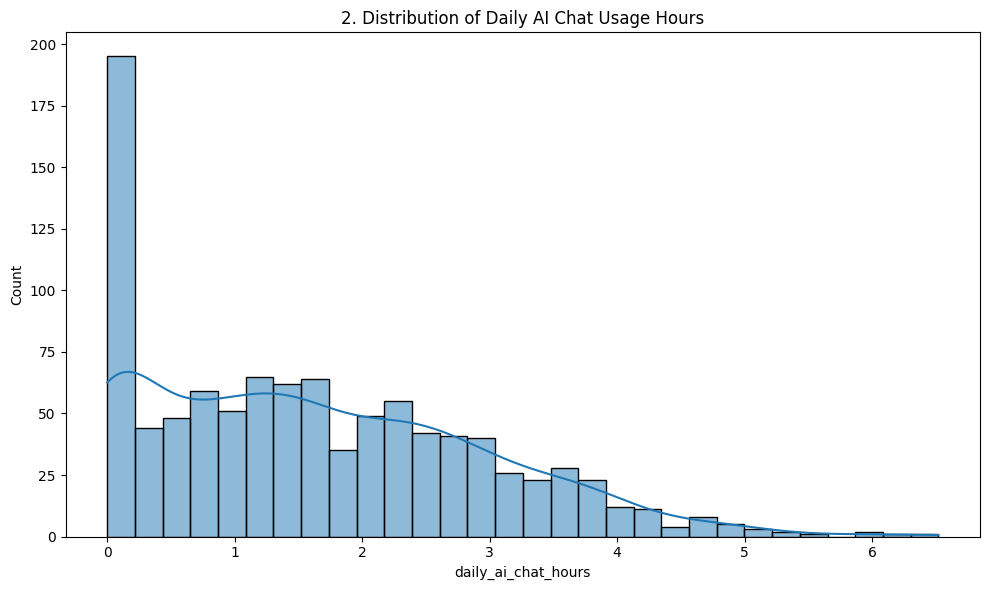

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['daily_ai_chat_hours'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Daily AI Chat Usage Hours')
show_fig()
plot_no += 1

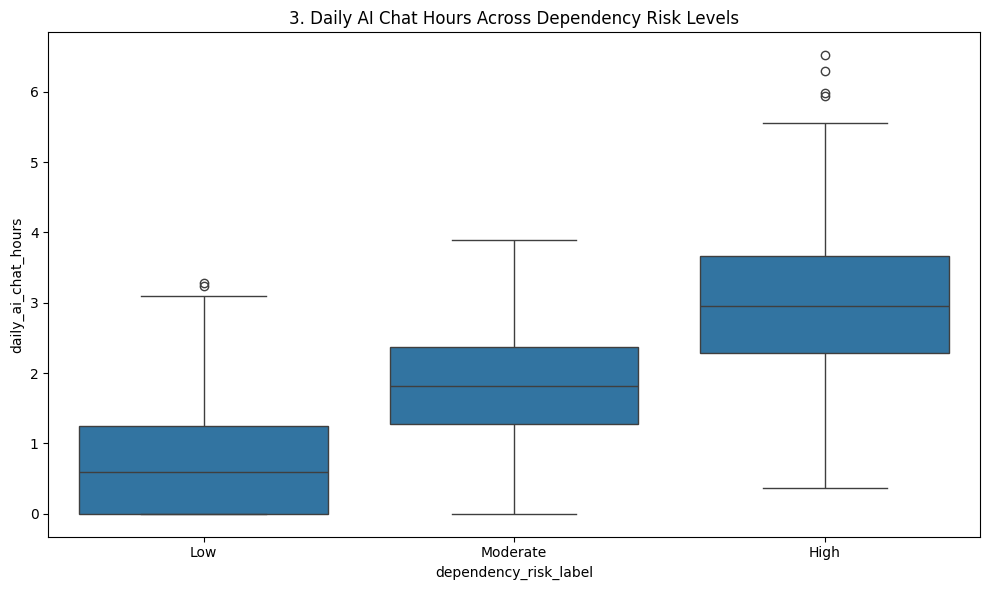

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='dependency_risk_label', y='daily_ai_chat_hours')
plt.title(f'{plot_no}. Daily AI Chat Hours Across Dependency Risk Levels')
show_fig()
plot_no += 1

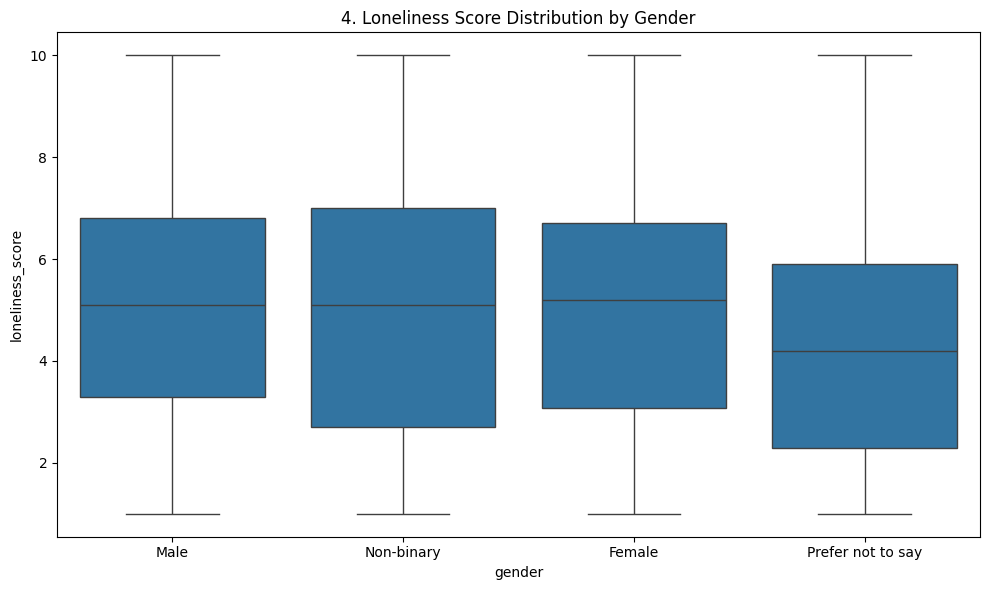

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='loneliness_score')
plt.title(f'{plot_no}. Loneliness Score Distribution by Gender')
show_fig()
plot_no += 1

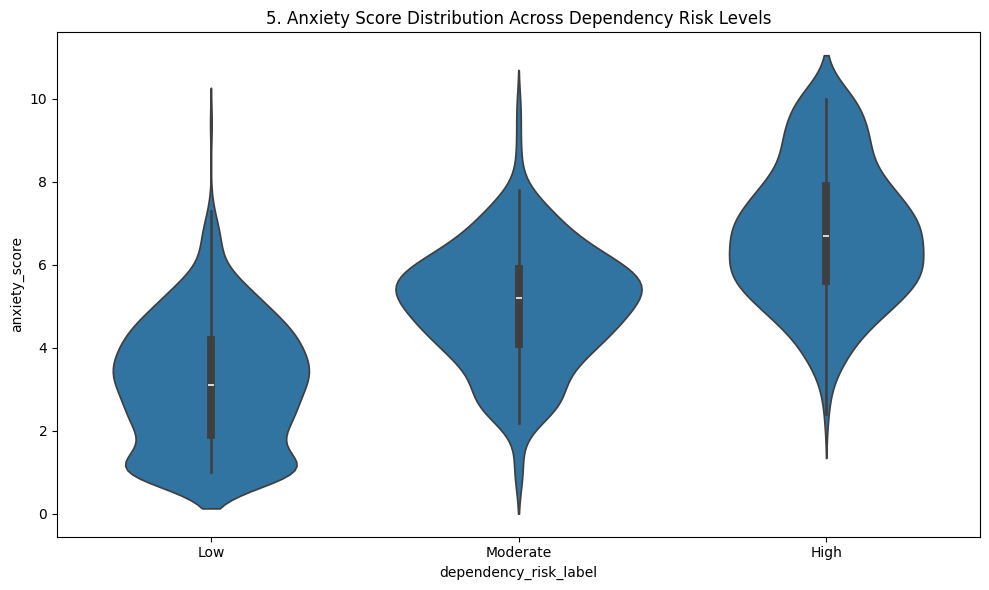

In [17]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='dependency_risk_label', y='anxiety_score')
plt.title(f'{plot_no}. Anxiety Score Distribution Across Dependency Risk Levels')
show_fig()
plot_no += 1

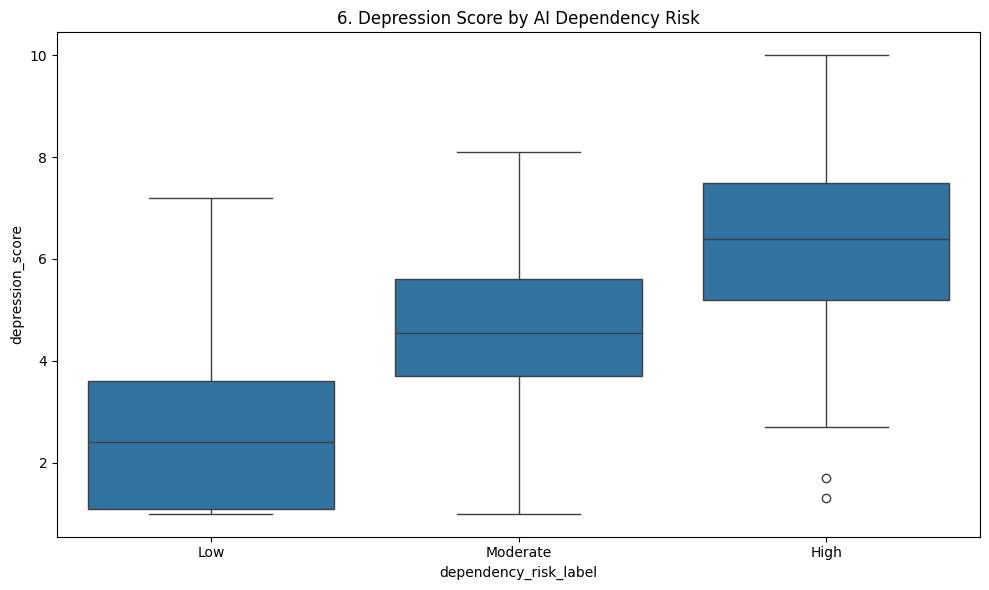

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='dependency_risk_label', y='depression_score')
plt.title(f'{plot_no}. Depression Score by AI Dependency Risk')
show_fig()
plot_no += 1

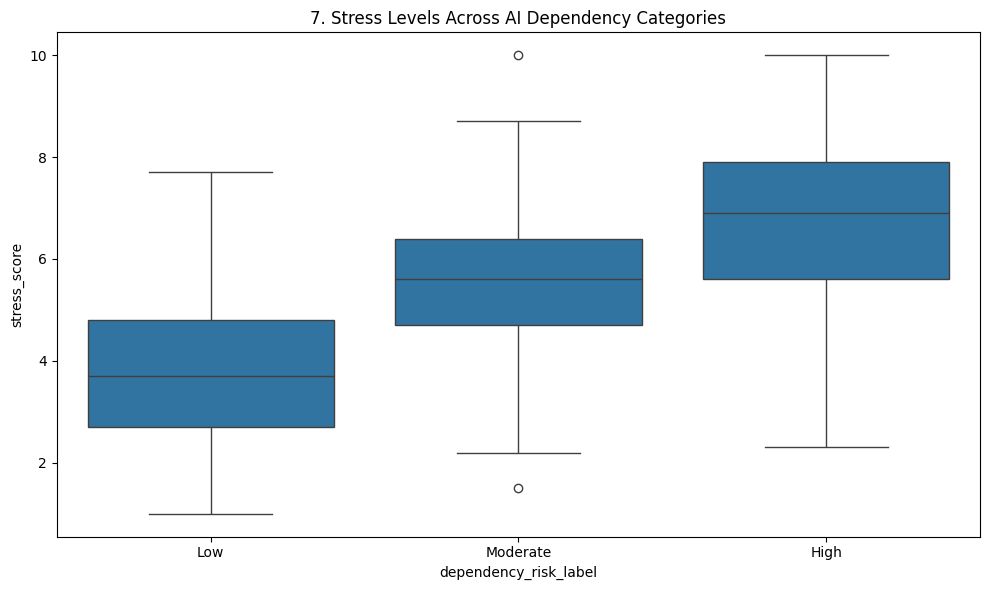

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='dependency_risk_label', y='stress_score')
plt.title(f'{plot_no}. Stress Levels Across AI Dependency Categories')
show_fig()
plot_no += 1

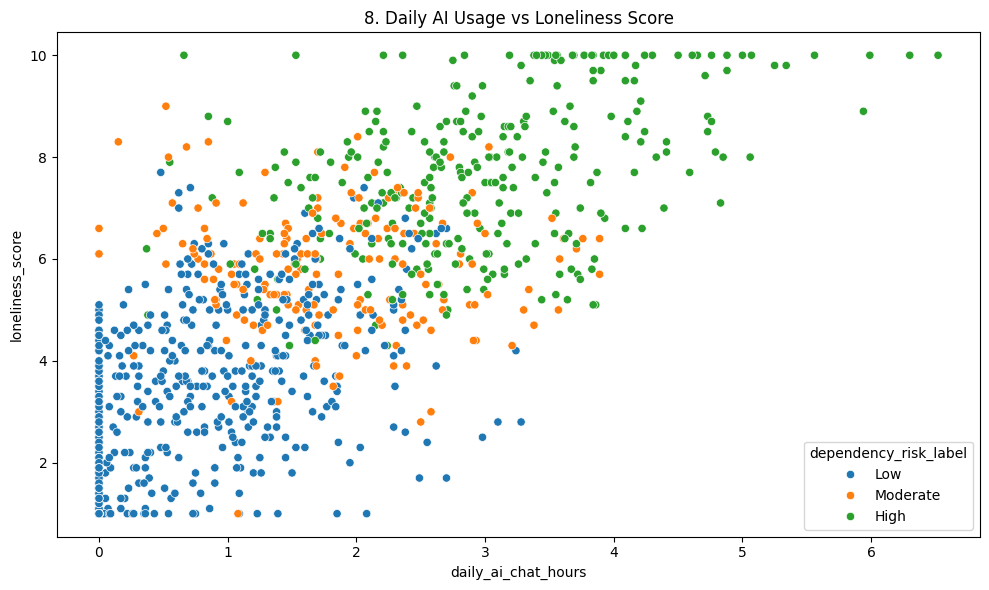

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='daily_ai_chat_hours', y='loneliness_score', hue='dependency_risk_label')
plt.title(f'{plot_no}. Daily AI Usage vs Loneliness Score')
show_fig()
plot_no += 1

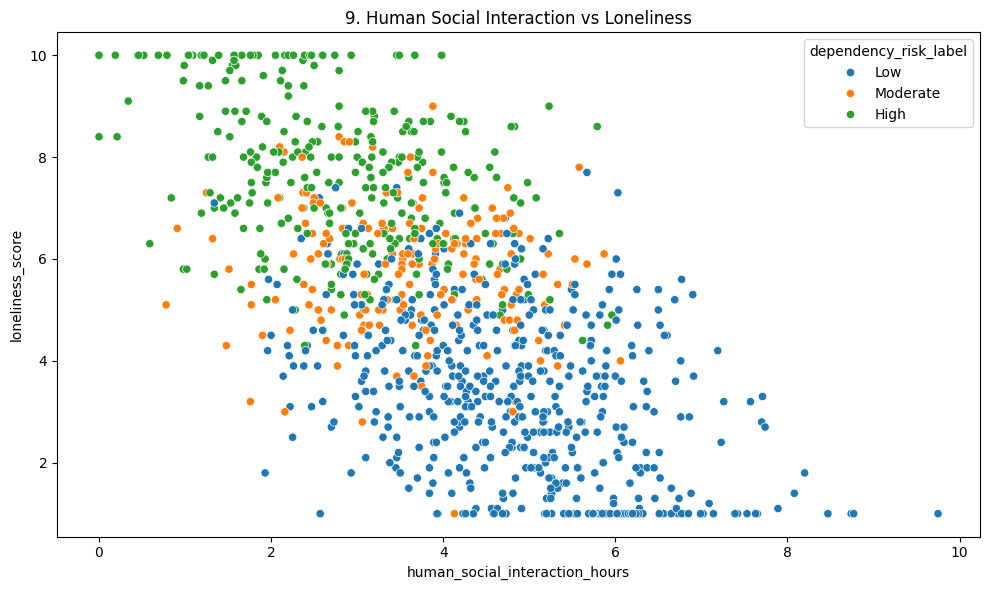

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='human_social_interaction_hours', y='loneliness_score', hue='dependency_risk_label')
plt.title(f'{plot_no}. Human Social Interaction vs Loneliness')
show_fig()
plot_no += 1

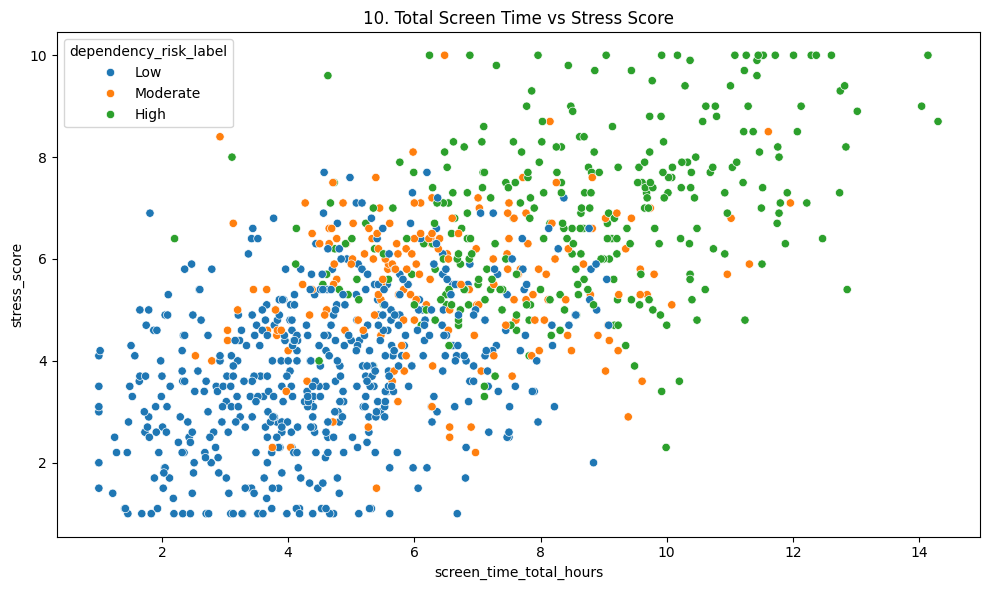

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='screen_time_total_hours', y='stress_score', hue='dependency_risk_label')
plt.title(f'{plot_no}. Total Screen Time vs Stress Score')
show_fig()
plot_no += 1

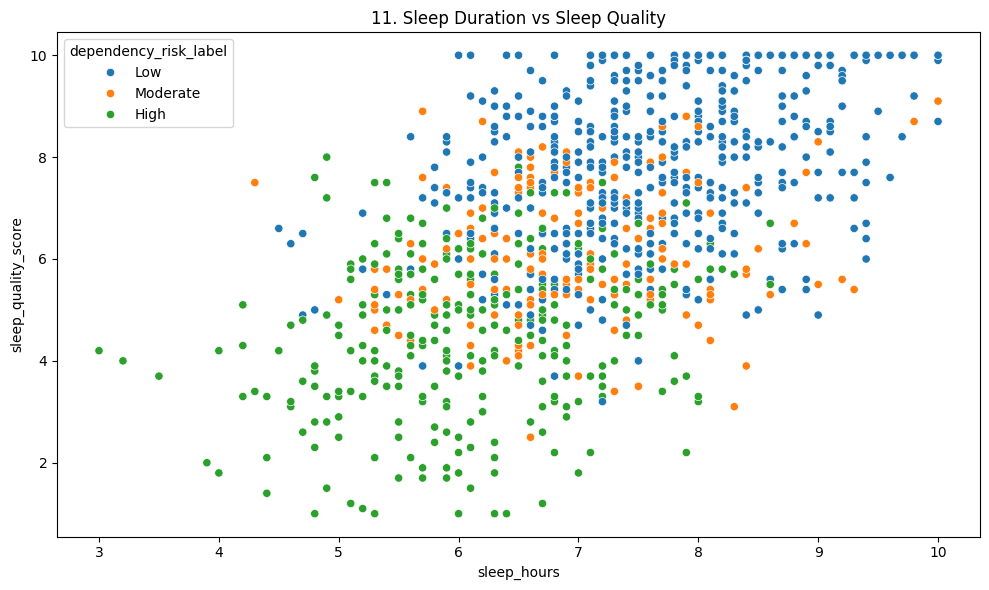

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sleep_hours', y='sleep_quality_score', hue='dependency_risk_label')
plt.title(f'{plot_no}. Sleep Duration vs Sleep Quality')
show_fig()
plot_no += 1

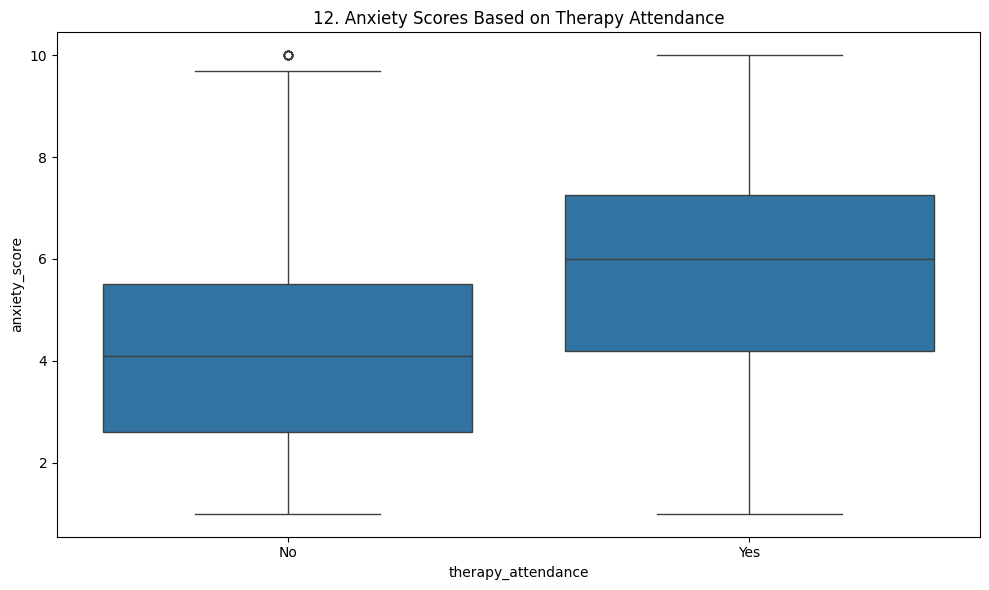

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='therapy_attendance', y='anxiety_score')
plt.title(f'{plot_no}. Anxiety Scores Based on Therapy Attendance')
show_fig()
plot_no += 1

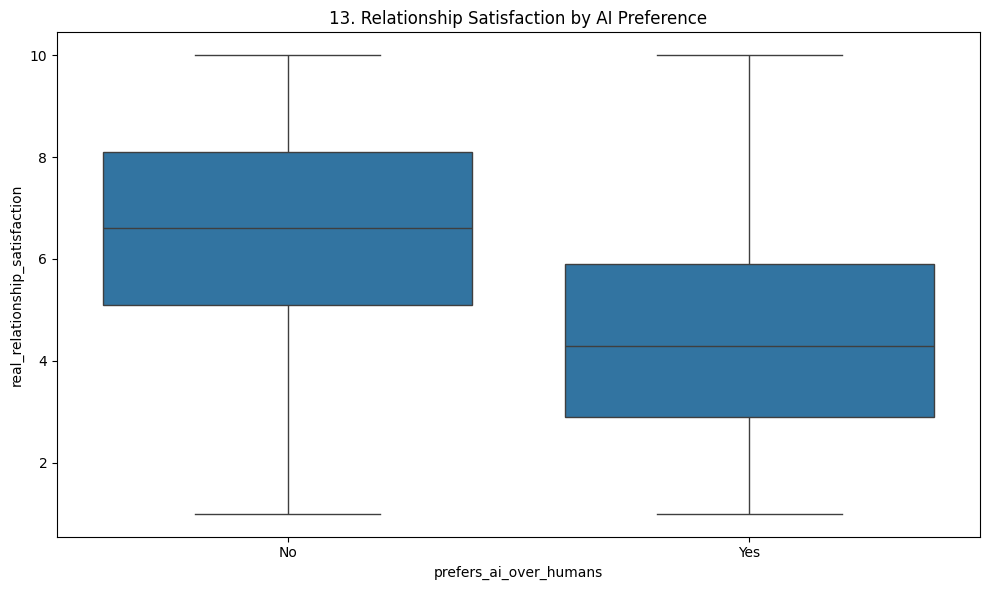

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='prefers_ai_over_humans', y='real_relationship_satisfaction')
plt.title(f'{plot_no}. Relationship Satisfaction by AI Preference')
show_fig()
plot_no += 1

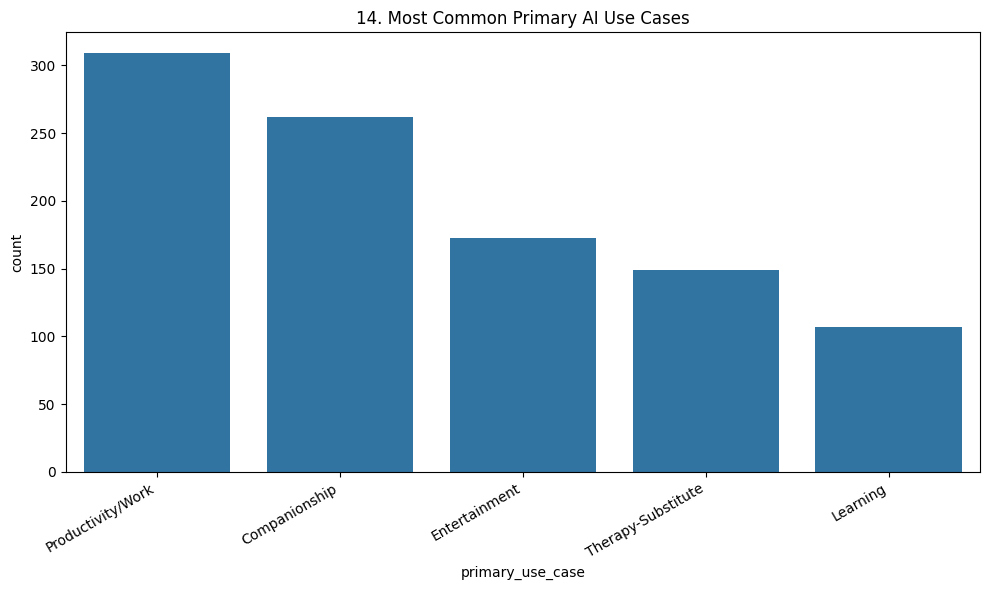

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='primary_use_case', order=df['primary_use_case'].value_counts().index)
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Most Common Primary AI Use Cases')
show_fig()
plot_no += 1

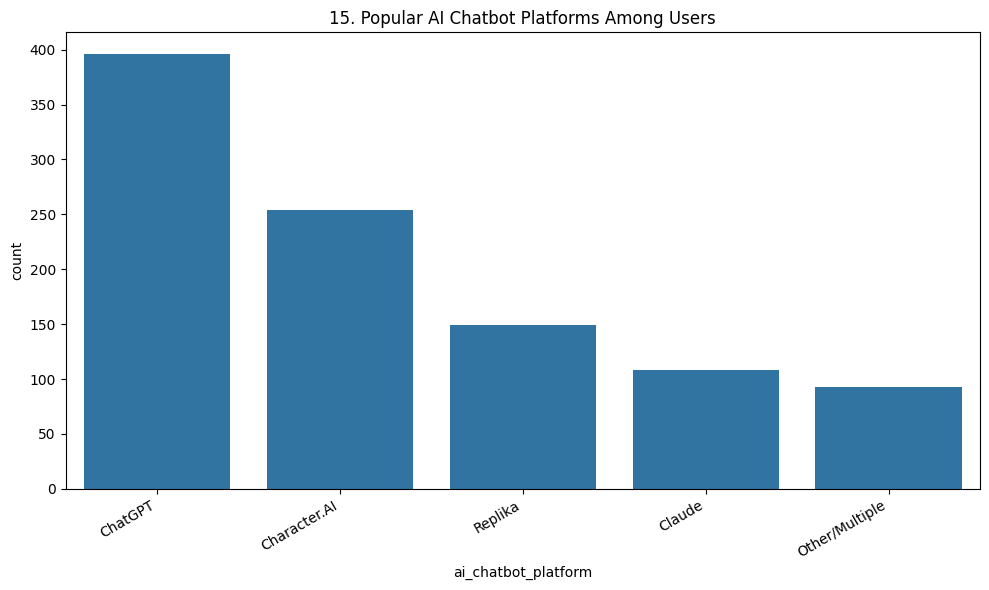

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='ai_chatbot_platform', order=df['ai_chatbot_platform'].value_counts().index)
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Popular AI Chatbot Platforms Among Users')
show_fig()
plot_no += 1

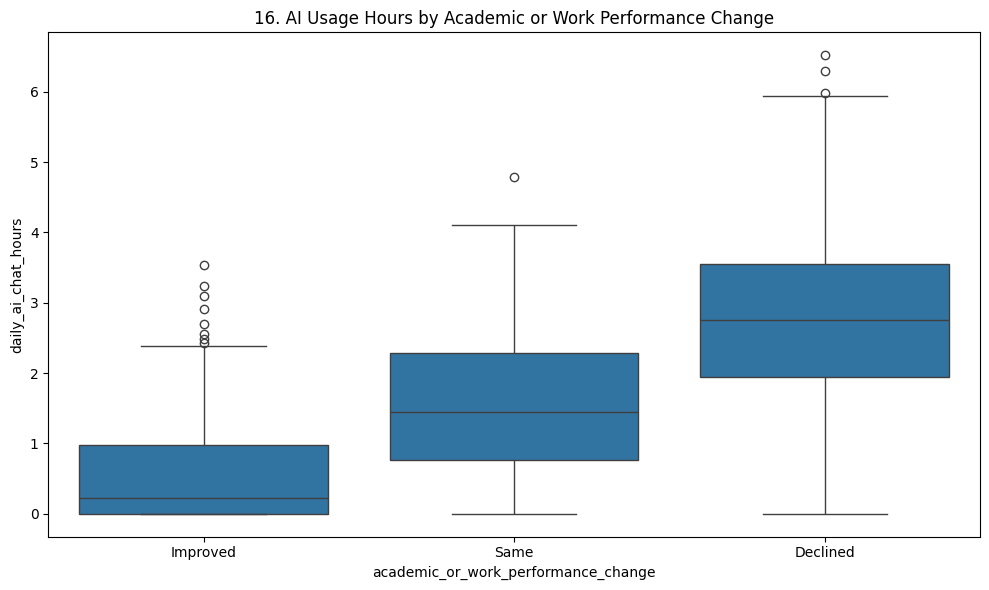

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='academic_or_work_performance_change', y='daily_ai_chat_hours')
plt.title(f'{plot_no}. AI Usage Hours by Academic or Work Performance Change')
show_fig()
plot_no += 1

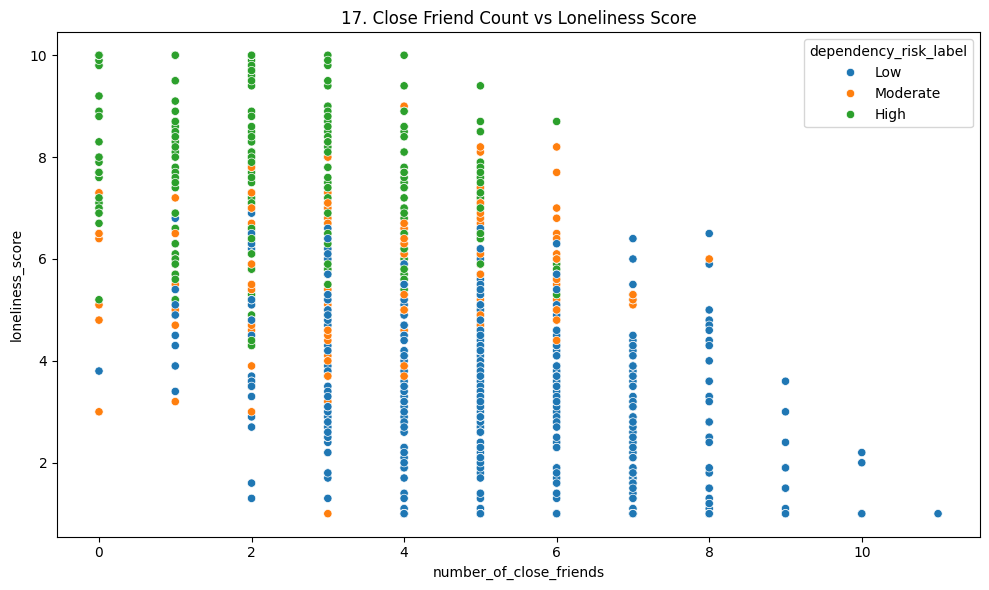

In [29]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='number_of_close_friends', y='loneliness_score', hue='dependency_risk_label')
plt.title(f'{plot_no}. Close Friend Count vs Loneliness Score')
show_fig()
plot_no += 1

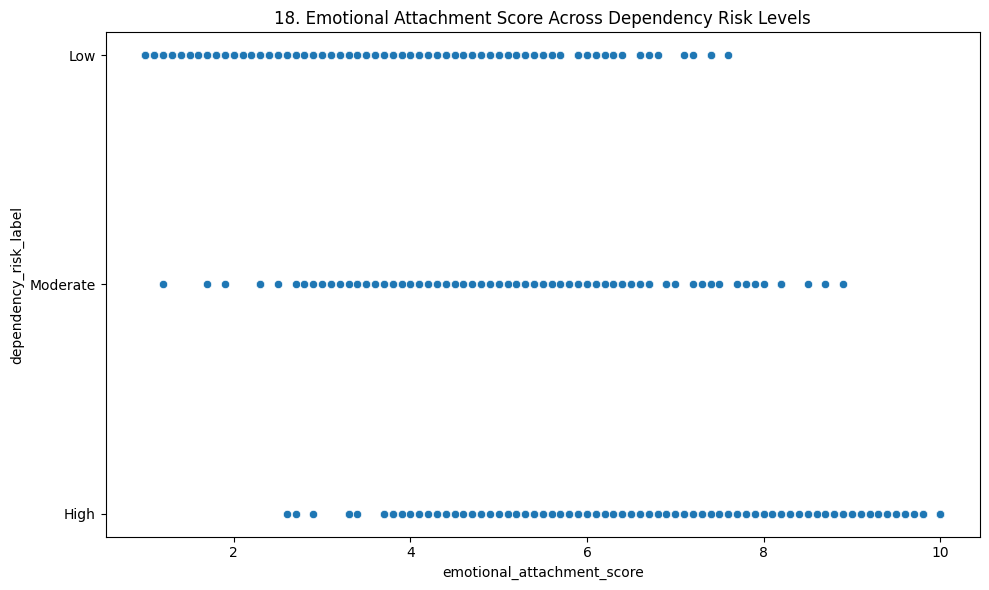

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='emotional_attachment_score', y='dependency_risk_label')
plt.title(f'{plot_no}. Emotional Attachment Score Across Dependency Risk Levels')
show_fig()
plot_no += 1

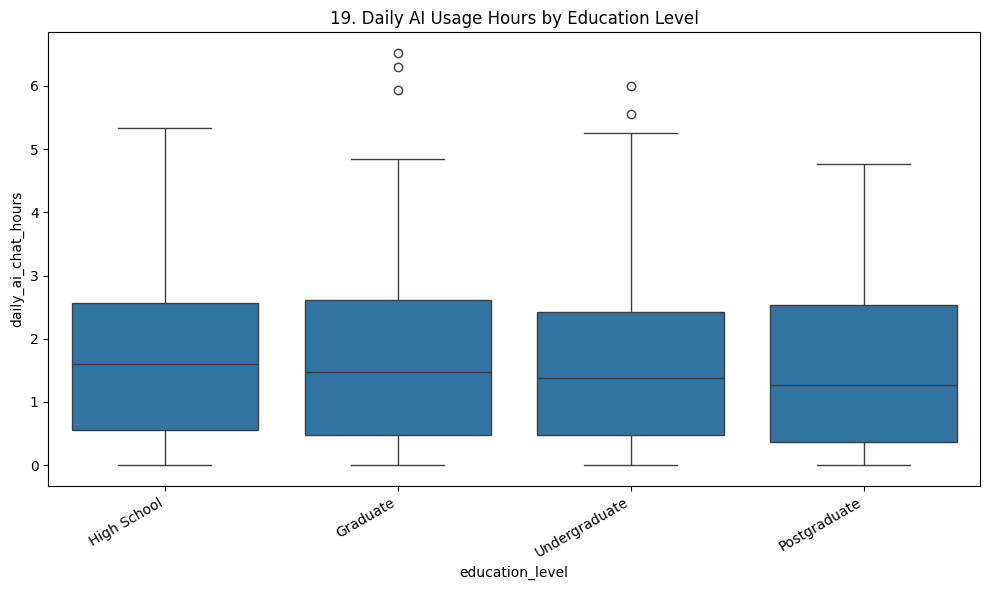

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='education_level', y='daily_ai_chat_hours')
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Daily AI Usage Hours by Education Level')
show_fig()
plot_no += 1

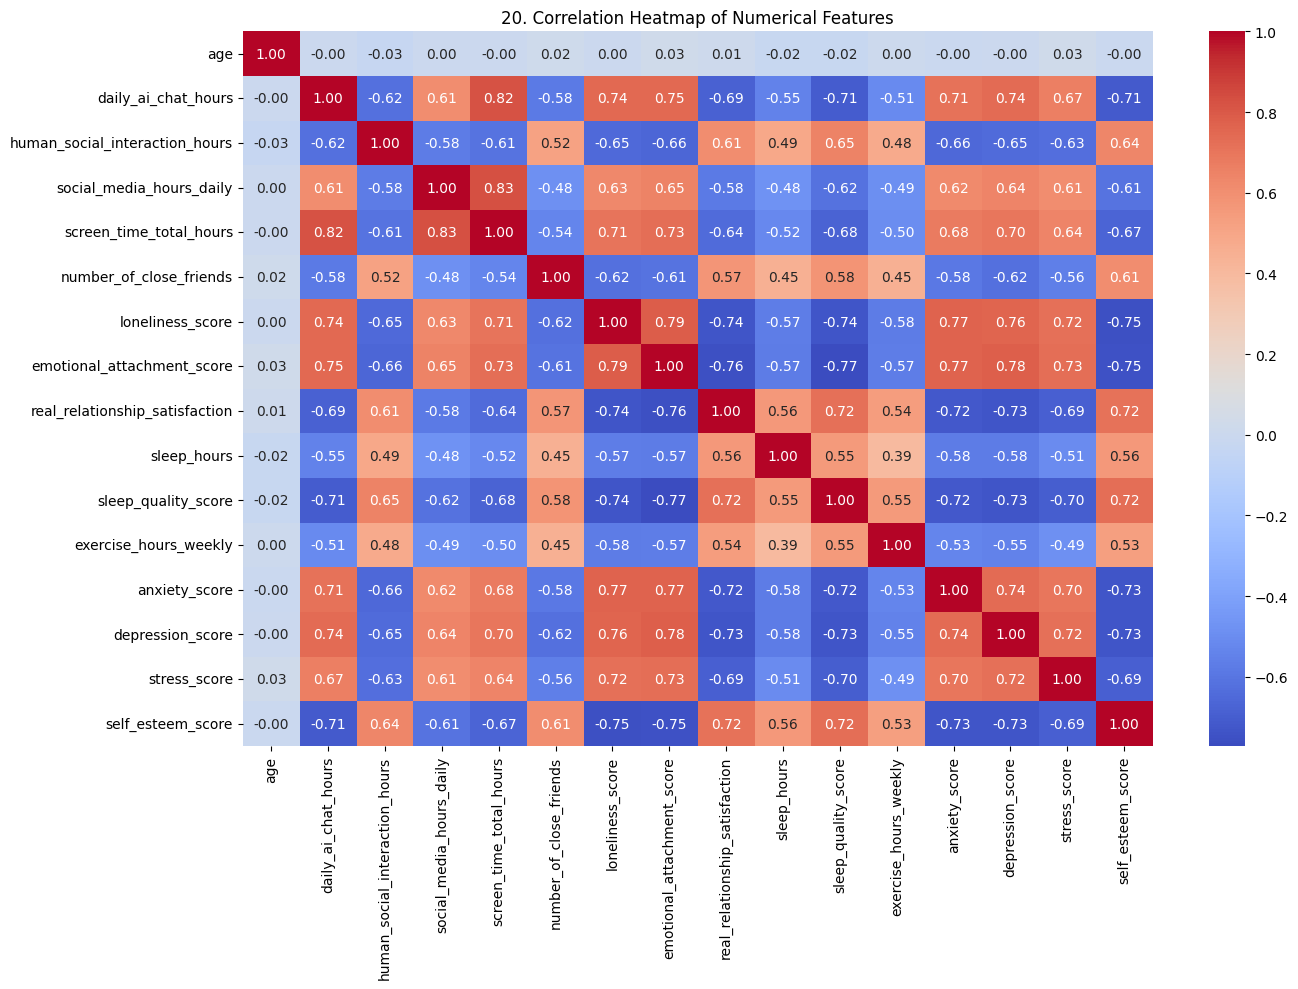

In [32]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

In [33]:
corr

,age,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,loneliness_score,emotional_attachment_score,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,anxiety_score,depression_score,stress_score,self_esteem_score
age,1.000000,-0.001069,-0.026945,0.003286,-0.003040,0.017721,0.001609,0.025649,0.014151,-0.018118,-0.024249,0.004919,-0.003979,-0.003415,0.028657,-0.003627
daily_ai_chat_hours,-0.001069,1.000000,-0.619695,0.606921,0.822551,-0.580967,0.744055,0.748170,-0.687770,-0.547331,-0.707419,-0.510483,0.713121,0.742677,0.666085,-0.712581
human_social_interaction_hours,-0.026945,-0.619695,1.000000,-0.576121,-0.611225,0.515660,-0.648561,-0.661931,0.605803,0.489068,0.649218,0.476570,-0.655813,-0.645420,-0.630012,0.638984
social_media_hours_daily,0.003286,0.606921,-0.576121,1.000000,0.832253,-0.483989,0.632951,0.653806,-0.582528,-0.475294,-0.616931,-0.491148,0.622611,0.642178,0.606458,-0.610821
screen_time_total_hours,-0.003040,0.822551,-0.611225,0.832253,1.000000,-0.536375,0.706010,0.726763,-0.644836,-0.519418,-0.675522,-0.497652,0.678260,0.702166,0.644085,-0.669979
number_of_close_friends,0.017721,-0.580967,0.515660,-0.483989,-0.536375,1.000000,-0.620500,-0.611913,0.573291,0.450290,0.579145,0.446816,-0.584876,-0.620008,-0.558346,0.607247
loneliness_score,0.001609,0.744055,-0.648561,0.632951,0.706010,-0.620500,1.000000,0.787140,-0.736662,-0.567515,-0.735769,-0.577548,0.766145,0.763335,0.718184,-0.752674
emotional_attachment_score,0.025649,0.748170,-0.661931,0.653806,0.726763,-0.611913,0.787140,1.000000,-0.756076,-0.572628,-0.771728,-0.569977,0.769883,0.778639,0.725317,-0.749302
real_relationship_satisfaction,0.014151,-0.687770,0.605803,-0.582528,-0.644836,0.573291,-0.736662,-0.756076,1.000000,0.559762,0.722608,0.539305,-0.717131,-0.731238,-0.690615,0.715637
sleep_hours,-0.018118,-0.547331,0.489068,-0.475294,-0.519418,0.450290,-0.567515,-0.572628,0.559762,1.000000,0.550893,0.392552,-0.575409,-0.576359,-0.507014,0.559060


# Model Training

## Set Target Columns

In [34]:
target = "dependency_risk_label"

## Separate Features and Target

In [35]:
X = df.drop(columns=[target])
y = df[target]

## Identify Numerical and Categorical Columns

In [36]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

## Create Numerical Preprocessing Pipeline

In [37]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Create Categorical Preprocessing Pipeline

In [38]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Combine Preprocessing Steps

In [39]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Split Dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Create SVM Classification Pipeline

In [41]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

## Train Model

In [42]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Make Predictions

In [43]:
y_pred = model.predict(X_test)

## Print Accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy : {accuracy:.4f}")
print(f"Accuracy Score : {accuracy*100:.2f}%")

Model Accuracy : 0.7950
Accuracy Score : 79.50%


## Print Classification Report

In [45]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        High       0.86      0.75      0.80        59
         Low       0.90      0.90      0.90       104
    Moderate       0.48      0.57      0.52        37

    accuracy                           0.80       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.81      0.80      0.80       200



## Plot Confusion Matrix

<Figure size 800x600 with 0 Axes>

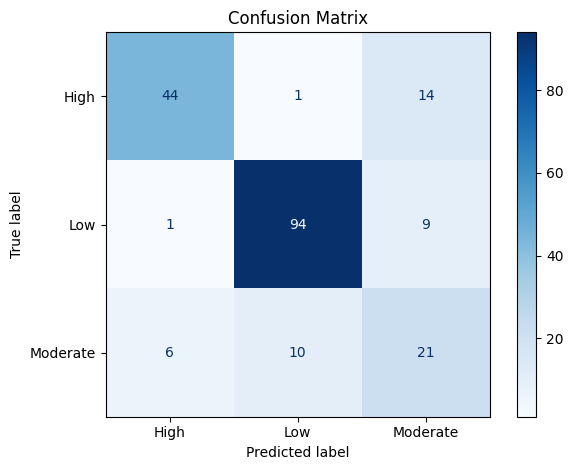

In [46]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()